In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import iirfilter, freqz, bilinear, butter, lfilter

(25000, 0.0016)

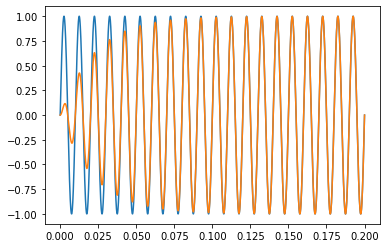

In [4]:
# SCIPY LFILTER
Q = 10
fs=int(125e3)
f0=100
total_time = 20/f0

f_in = f0

t = np.linspace(0,total_time,int(total_time*fs))
x_in = np.sin(2*np.pi*f_in*t)


#LOWPASS
b,a  = iirfilter(1, f0/(fs/2), btype='low', ftype='butter')


omega_0 = 2 * np.pi * f0
num = np.array([omega_0**2])  # numerator: [omega_0^2]
den = np.array([1, omega_0 / Q, omega_0**2])*Q  # denominator: [1, 2 * zeta * omega_0, omega_0^2]
b, a = bilinear(num, den, fs)


omega_0 = 2 * np.pi * f0
num = np.array([0,omega_0,0])/Q*np.sqrt(2)  # numerator: [omega_0^2]
den = np.array([1, np.sqrt(2) * omega_0 /Q, omega_0**2])  # denominator: [1, 2 * zeta * omega_0, omega_0^2]
b, a = bilinear(num, den, fs)

y = lfilter(b,a,x_in)

plt.plot(t,x_in)
#plt.plot(t,x_in/np.sqrt(2))
plt.plot(t,y)

len(t), f0/(fs/2)

In [5]:
#FILTER PARAMETERS

Q = 100
fs=int(125e3)
f0=1
total_time = 50/f0

f_in = f0

t = np.linspace(0,total_time,int(total_time*fs))
x_in = np.sin(2*np.pi*f_in*t)


omega_0 = 2 * np.pi * f0
num = np.array([0,omega_0,0])/Q*np.sqrt(2)  # numerator: [omega_0^2]
den = np.array([1, np.sqrt(2) * omega_0 /Q, omega_0**2])  # denominator: [1, 2 * zeta * omega_0, omega_0^2]



(array([ 1073741823, -2147482880,  1073741060], dtype=int64),
 array([ 382,    0, -382]))

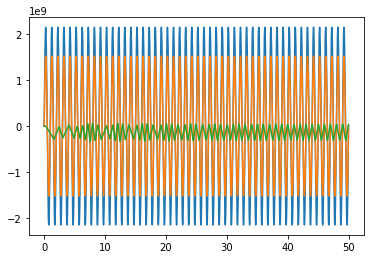

In [93]:
# IMPLEMENTATION IN DIRECT FORM II, explicit

DATA_WIDTH = 32
COEFF_WIDTH = 32
LOG_A0 = COEFF_WIDTH-2


b, a = bilinear(num, den, fs)
b = np.round(b * (2**LOG_A0-1)).astype(np.int32)
a = np.round(a * (2**LOG_A0-1)).astype(np.int64)

x_in = ((np.sin(2*np.pi*f0*t))* (2**(DATA_WIDTH - 1) - 1)).astype(np.int64)
y = np.zeros_like(x_in, dtype = 'int64')

#b0_x0 = b1_x1 = b2_x2 = a1_y1 = a2_y2 = np.int64(0)

for n in range(len(x_in)):

    #Combinational multiplications
    b0_x0 = x_in[n-0] * b[0]
    b1_x1 = x_in[n-1] * b[1]
    b2_x2 = x_in[n-2] * b[2]
    a1_y1 =    y[n-1] * a[1]
    a2_y2 =    y[n-2] * a[2]
    
    #Filter equation 

    acc = b0_x0 + b1_x1 + b2_x2 - a1_y1 - a2_y2
    y[n] = acc >> LOG_A0

y_out = np.clip(y, -2**(DATA_WIDTH - 1), 2**(DATA_WIDTH - 1) - 1).astype(np.int32)


plt.plot(t,x_in)
plt.plot(t,x_in/np.sqrt(2))
plt.plot(t,y)
a,b
#plt.xlim(2,3)

(array([  8388607, -16777152,   8388547], dtype=int64), array([ 30,   0, -30]))

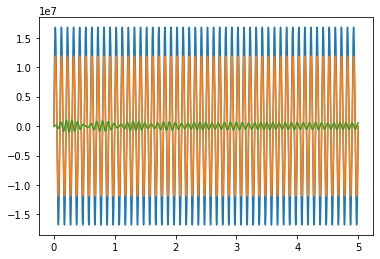

In [5]:
# IMPLEMENTATION IN DIRECT FORM II, with intermediate state

DATA_WIDTH = 25
COEFF_WIDTH = 25
LOG_A0 = COEFF_WIDTH-2


b, a = bilinear(num, den, fs)
b = np.round(b * (2**LOG_A0-1)).astype(np.int32)
a = np.round(a * (2**LOG_A0-1)).astype(np.int64)

x_in = ((np.sin(2*np.pi*f0*t))* (2**(DATA_WIDTH - 1) - 1)).astype(np.int64)
y = np.zeros_like(x_in, dtype = 'int64')
w = np.zeros_like(x_in, dtype = 'int64')
w0 = w1 = w2 = np.int64(0)

scaling_factor = 32

for n in range(len(x_in)):
    
    #Filter equation 
    w0 = x_in[n] - a[1]*w1 - a[2]*w2
    w0 = w0 >> LOG_A0
    
    y[n] = b[0]*w0 + b[1]*w1 + b[2]*w2
    w2 = w1
    w1 = w0
    

    #w[n] = x_in[n] - a[1]*w[n-1] - a[2]*w[n-2]
    #w[n] = w[n] >> LOG_A0
    #acc = b[0]*w[n] + b[1]*w[n-1] + b[2]*w[n-2]
    
    

y_out = np.clip(y, -2**(DATA_WIDTH - 1), 2**(DATA_WIDTH - 1) - 1).astype(np.int32)


plt.plot(t,x_in)
plt.plot(t,x_in/np.sqrt(2))
plt.plot(t,y)
a,b

(array([  8388607, -16777152,   8388547], dtype=int64),
 array([ 30,   0, -30], dtype=int64))

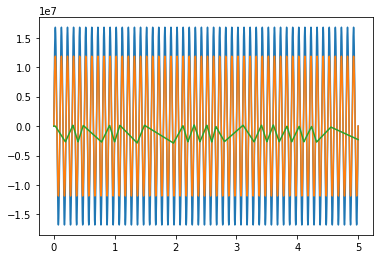

In [81]:
# IMPLEMENTATION IN TRANSPOSED DIRECT FORM II
DATA_WIDTH = 25
COEFF_WIDTH = 25
LOG_A0 = COEFF_WIDTH-2


b, a = bilinear(num, den, fs)
b = np.round(b * (2**LOG_A0-1)).astype(np.int64)
a = np.round(a * (2**LOG_A0-1)).astype(np.int64)

x_in = ((np.sin(2*np.pi*f0*t))* (2**(DATA_WIDTH - 1) - 1)).astype(np.int64)
y = np.zeros_like(x_in, dtype = 'int64')
w0 = np.zeros_like(x_in, dtype = 'int64')
w1 = np.zeros_like(x_in, dtype = 'int64')
w2 = np.zeros_like(x_in, dtype = 'int64')
s1 = s2 = np.int64(0)

for n in range(len(x_in)):
    
    #Filter equation 

    #w0[n] = x_in[n] - a[1]*w1[n-1] - a[2]*w2[n-1]

    #w1[n] = w0[n] + b[1]*w1[n-1]
    
    #w2[n] = w1[n] + b[2]*w2[n-1]
    
    #acc = (b[0]*w0[n]) + w1[n] + w2[n]
    #y[n] = acc


    acc = s1 + b[0] * x_in[n]
    y[n] = acc >> LOG_A0  

    # Update states
    s1 = s2 + (b[1] * x_in[n]) - (a[1] * y[n])
    s2 = (b[2] * x_in[n]) - (a[2] * y[n])

y_out = np.clip(y, -2**(DATA_WIDTH - 1), 2**(DATA_WIDTH - 1) - 1).astype(np.int32)


plt.plot(t,x_in)
plt.plot(t,x_in/np.sqrt(2))
plt.plot(t,y)
a,b

In [1]:
#FILTER PARAMETERS

Q = 30
fs=int(125e3)
f0=10
total_time = 50/f0

f_in = f0

t = np.linspace(0,total_time,int(total_time*fs))
x_in = np.sin(2*np.pi*f_in*t)


omega_0 = 2 * np.pi * f0
num = np.array([0,1,0])/Q*np.sqrt(2) 
den = np.array([1, np.sqrt(2) * omega_0 /Q, omega_0**2])  

NameError: name 'np' is not defined

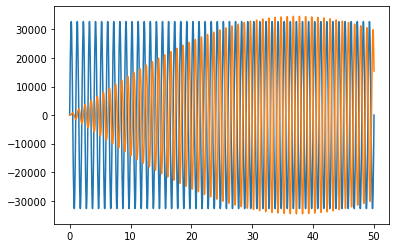

In [7]:
#COUPLED FORM
#the coupled form is not a general filter, but a specif case of a second order filter, where the poles are complex conjugate.
#It requires much smaller resolution in the coefficient and input states, at the cost of having a state variable that can be very large.
#But the multiplcation are much smaller!


DATA_WIDTH = 16
COEFF_WIDTH = 20
LOG_A0 = COEFF_WIDTH-2
EXTRA = 1

b, a = bilinear(num, den, fs)

# Compute alpha and beta c1 and c2
alpha = -a[1] / 2
beta = np.sqrt(a[2] - (a[1]**2) / 4)
c1 = 0
c2 = np.sqrt(1-2*a[2]+a[2]**2)

alpha = int(round(alpha * (1 << LOG_A0)))
beta = int(round(beta * (1 << LOG_A0)))
#c1 = int(round(c1 * (1 << LOG_A0)))
#c2 = int(round(c2 * (1 << LOG_A0)))

x_in = ((np.sin(2*np.pi*f0*t))* (2**(DATA_WIDTH - 1) - 1)).astype(np.int64)
y = np.zeros_like(x_in, dtype = 'int64')
sl1 = np.zeros_like(x_in, dtype = 'int64')
sl2 = np.zeros_like(x_in, dtype = 'int64')
s1 = s2 = np.int32(0)
s1_new = s2_new = np.int32(0)



for n in range(len(x_in)):

    #if (alpha * s1 - beta * s2)>2**(DATA_WIDTH+COEFF_WIDTH+EXTRA):
    #     print('overflow1',alpha * s1 - beta * s2, s1, s2); break
    #if (beta * s1 + alpha * s2)>2**(DATA_WIDTH+COEFF_WIDTH+EXTRA): print('overflow2'); break
    #if (c1 * s1_new + c2 * s2_new)>2**(DATA_WIDTH+COEFF_WIDTH+EXTRA): print('overflow');break

    s1_new = (alpha * s1 - beta * s2) >> (LOG_A0)
    s1_new += x_in[n]  # Add input (no scaling needed for input)
    s2_new = (beta * s1 + alpha * s2) >>  (LOG_A0)

    # Output equation
    y[n] = (c1 * s1_new + c2 * s2_new) #>>  (LOG_A0)


    # Update state variables
    s1 = s1_new
    s2 = s2_new

    sl1[n] = s1
    sl2[n] = s2 




plt.plot(t,x_in)
plt.plot(t,y)

#plt.plot(t,x_in*2**LOG_A0/625)
#plt.plot(t,sl1)
#plt.plot(t,sl2)
#plt.xlim(0.4,0.45)



(0.007812470197677612, 132)

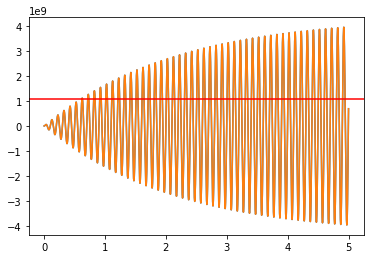

In [165]:
plt.plot(t,alpha*sl1>>LOG_A0)
plt.plot(t,sl1)
plt.axhline(2**(30), color='r')

alpha/2**25, beta

In [12]:

Q = 30
fs=int(125e3)
f0=10
total_time = 50/f0

f_in = f0

t = np.linspace(0,total_time,int(total_time*fs))
x_in = np.sin(2*np.pi*f_in*t)

omega_0 = 2 * np.pi * f0
num = np.array([0,1,0])/Q*np.sqrt(2) 
den = np.array([1, np.sqrt(2) * omega_0 /Q, omega_0**2])  

b, a = bilinear(num, den, fs)

# Compute alpha and beta c1 and c2
alpha = -a[1] / 2
beta = np.sqrt(a[2] - (a[1]**2) / 4)
c1 = 0
c2 = np.sqrt(1-2*a[2]+a[2]**2)

c2,  int(round(c2 * (1 << LOG_A0))), alpha*2**18, beta*2**18, 

N=17
al = int(alpha*(1 << N)+0.5)
be = int(beta**(1 << N)+0.5)

np.sqrt(al**2 + be**2)/((1 << N))
c2*2**23

198.76884737679595

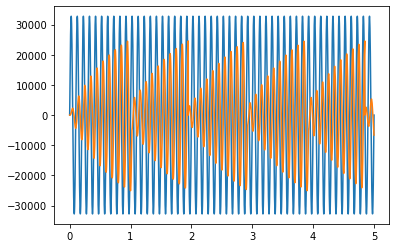

In [13]:
#COUPLED FORM
#the coupled form is not a general filter, but a specif case of a second order filter, where the poles are complex conjugate.
#It requires much smaller resolution in the coefficient and input states, at the cost of having a state variable that can be very large.
#But the multiplcation are much smaller!


DATA_WIDTH = 16
COEFF_WIDTH = 20
LOG_A0 = COEFF_WIDTH-2
EXTRA = 14

b, a = bilinear(num, den, fs)

# Compute alpha and beta c1 and c2
alpha = -a[1] / 2
beta = np.sqrt(a[2] - (a[1]**2) / 4)
c1 = 0
c2 = np.sqrt(1-2*a[2]+a[2]**2)

alpha = int(round(alpha * (1 << LOG_A0)))
beta = int(round(beta * (1 << LOG_A0)))
c1 = int(round(c1 * (1 << LOG_A0)))
c2 = int(round(c2 * (1 << LOG_A0)))

x_in = ((np.sin(2*np.pi*f0*t))* (2**(DATA_WIDTH - 1) - 1)).astype(np.int64)

#x_in = np.zeros(len(t), dtype = 'int64')
#x_in[10000:50000] =(2**(DATA_WIDTH - 1) - 1)

y = np.zeros_like(x_in, dtype = 'int64')
sl1 = np.zeros_like(x_in, dtype = 'int64')
sl2 = np.zeros_like(x_in, dtype = 'int64')
v0 = v1 = v2 = np.int64(0)
s1 = s2 = np.int32(0)
s1_new = s2_new = np.int64(0)



for n in range(len(x_in)):

    #if (alpha * s1 - beta * s2)>2**(DATA_WIDTH+COEFF_WIDTH+EXTRA): print('overflow'); break
    #if (beta * s1 + alpha * s2)>2**(DATA_WIDTH+COEFF_WIDTH+EXTRA): print('overflow'); break
    #if (c1 * s1_new + c2 * s2_new)>2**(DATA_WIDTH+COEFF_WIDTH+EXTRA): print('overflow');break

    alpha_s1 = alpha * s1 >> LOG_A0
    beta_s2 = beta * s2 >> LOG_A0
    beta_s1 = beta * s1 >> LOG_A0
    alpha_s2 = alpha * s2 >> LOG_A0

    s1_new = x_in[n]  + alpha_s1 - beta_s2
    s2_new = beta_s1 + alpha_s2

    # Output equation
    y[n] = (c1 * s1_new + c2 * s2_new) >> LOG_A0


    # Update state variables

    if s1_new > 2**(DATA_WIDTH+EXTRA):
        s1_new = s1_new & ((1 << DATA_WIDTH+EXTRA) - 1)
        #s1_new = s1_new >>10;# print('overflow s1')
    if s2_new > 2**(DATA_WIDTH+EXTRA):
        s2_new = s2_new & ((1 << DATA_WIDTH+EXTRA) - 1)
        #s2_new  = s2_new >>10;# print('overflow s2')

    s1 = s1_new
    s2 = s2_new

    sl1[n] = s1
    sl2[n] = s2 




plt.plot(t,x_in)
plt.plot(t,y)

#plt.plot(t,x_in*2**LOG_A0/625)
#plt.plot(t,sl1)
#plt.plot(t,sl2)
#plt.xlim(0.4,0.45)



In [15]:
alpha, beta, c1, c2

(262141, 132, 0, 6)

In [451]:
omega_0 = 2 * np.pi * f0
num = np.array([0,omega_0,0])/Q*np.sqrt(2) 
den = np.array([1, np.sqrt(2) * omega_0 /Q, omega_0**2])  
b, a = bilinear(num, den, fs)
alpha = -a[1] / 2
beta = np.sqrt(a[2] - (a[1]**2) / 4)
alpha, beta
omega = omega_0/fs
H = beta*np.exp(1j * omega) / (1- 2*alpha*np.exp(1j * omega) + (alpha**2+beta**2)*np.exp(2j * omega))
np.abs(H), 1/np.sqrt(1-2*a[2]+a[2]**2)


theta = 2*np.pi*f0/fs
r1 = alpha / np.cos(theta)
r2 = beta / np.sin(theta)
r1,r2

H = beta*np.exp(1j * omega) / (1- 2*alpha*np.exp(1j * omega) + (alpha**2+beta**2)*np.exp(2j * omega))
np.abs(H), 1/np.sqrt(1-2*a[2]+a[2]**2)

(1406709.0688121687, 1406674.9654496908)

In [443]:
H = beta1*np.exp(1j * omega) / (1- 2*alpha1*np.exp(1j * omega) + (alpha1**2+beta1**2)*np.exp(2j * omega))
np.abs(H), 1/np.sqrt(1-2*a[2]+a[2]**2)

(452751215939.1652, 1406674.9654496908)

(array([ 1073741823, -2147475742,  1073734190], dtype=int64),
 array([ 3816,     0, -3816], dtype=int64))

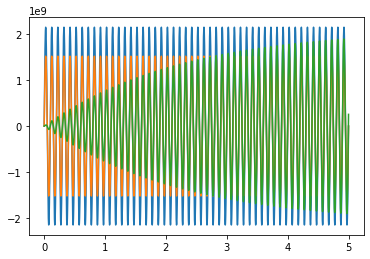

In [27]:
# DIGITAL FOR LOOP, NO PIPELINE


Q = 100
sf=int(125e3)
f0=10
total_time = 50/f0

f_in = 0.1*f0

t = np.linspace(0,total_time,int(total_time*sf))
x_in = np.sin(2*np.pi*f_in*t)


data_bit_depth = 32
coeff_bit_depth = 32
deltab = 0
bitshift = coeff_bit_depth-2



omega_0 = 2 * np.pi * f0
num = np.array([0,omega_0,0])/Q*np.sqrt(2)  # numerator: [omega_0^2]
den = np.array([1, np.sqrt(2) * omega_0 /Q, omega_0**2])  # denominator: [1, 2 * zeta * omega_0, omega_0^2]

#num = np.array([omega_0**2])  # numerator: [omega_0^2]
#den = np.array([1, omega_0 / Q, omega_0**2])*Q  # denominator: [1, 2 * zeta * omega_0, omega_0^2]

b, a = bilinear(num, den, sf)


#b,a  = iirfilter(1, f0/(sf/2), btype='low', ftype='butter')

b = np.round(b * (2**(bitshift+deltab)-1)).astype(np.int64)

a = np.round(a * (2**bitshift-1)).astype(np.int64)

x_in = ((np.sin(2*np.pi*f0*t))* (2**(data_bit_depth - 1) - 1)).astype(np.int64)

acc = np.zeros_like(x_in, dtype = 'int64')
acc_temp = np.zeros_like(x_in, dtype = 'int64')


for n in range(len(x_in)):
    # Apply the filter difference equation

    acc[n] = sum( (int(b[i] * x_in[n - i])>>deltab ) if n - i >= 0 else 0 for i in range(len(b)))
    #acc[n] = sum( limit_bit_depth(int(b[i] * x_in[n - i]) , coeff_bit_depth + data_bit_depth) if n - i >= 0 else 0 for i in range(len(b)))

    acc[n] -= sum( (int(a[i] * acc[n - i]) ) if n - i >= 0 else 0 for i in range(1, len(a)))
    #acc[n] -= sum( limit_bit_depth(int(a[i] * acc[n - i]) , coeff_bit_depth + data_bit_depth) if n - i >= 0 else 0 for i in range(1, len(a)))
    
    acc[n] = (acc[n]>>bitshift)
    #acc[n] = limit_bit_depth((acc[n]>>bitshift), data_bit_depth)

y = np.clip(acc, -2**(data_bit_depth - 1), 2**(data_bit_depth - 1) - 1).astype(np.int32)


plt.plot(t,x_in)
plt.plot(t,x_in/np.sqrt(2))
plt.plot(t,y)
a,b

In [14]:
r = np.exp(-np.pi*f0/(sf*Q))
Bc = np.log2(1/(1-r))
r, f0, Q, sf, Bc

(0.9999974867290354, 10, 100, 125000, 18.602002347703095)

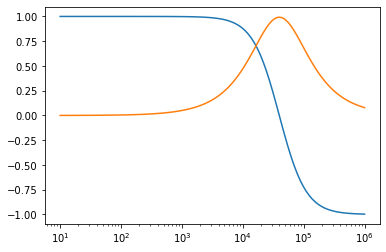

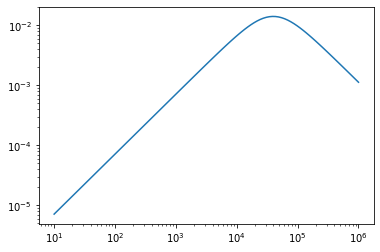

In [188]:
alpha_list =[]
beta_list = []
clist = []
Qlist = np.logspace(1,6,100)
Q = 100
f0=10

for f0 in Qlist:
    fs=int(125e3)
    total_time = 50/f0

    f_in = f0

    t = np.linspace(0,total_time,int(total_time*fs))
    x_in = np.sin(2*np.pi*f_in*t)

    omega_0 = 2 * np.pi * f0
    num = np.array([0,1,0])/Q*np.sqrt(2) 
    den = np.array([1, np.sqrt(2) * omega_0 /Q, omega_0**2])  

    b, a = bilinear(num, den, fs)

    # Compute alpha and beta c1 and c2
    alpha = -a[1] / 2
    beta =  np.sqrt(a[2] - (a[1]**2) / 4)
    c = np.sqrt(1-2*a[2]+a[2]**2)

    alpha_list.append(alpha)
    beta_list.append(beta)
    clist.append(c)

plt.plot(Qlist,alpha_list)

plt.plot(Qlist, np.abs(beta_list))

plt.xscale('log')

plt.figure()
plt.plot(Qlist,clist)
plt.yscale('log')
plt.xscale('log')


1024.0

In [184]:
IN_DATA_WIDTH = 16
DATA_WIDTH = 32
COEFF_WIDTH = 32
ACC_WIDTH = DATA_WIDTH + COEFF_WIDTH
LOG_A0 = 30 


b,a  = iirfilter(1, f0/(sf/2), btype='low', ftype='butter')


b = np.round(b * (2**LOG_A0-1)).astype('int32')
a = np.round(a * (2**LOG_A0-1)).astype('int32')

b = np.pad(b, (0, 3 - len(b)), 'constant')
a = np.pad(a, (0, 3 - len(a)), 'constant')


iir_dict = {}
_, iir_dict['iir_a1'],iir_dict['iir_a2'] = a
iir_dict['iir_b0'], iir_dict['iir_b1'],iir_dict['iir_b2'] = b

a = [0, iir_dict['iir_a1'],iir_dict['iir_a2']]
b = [iir_dict['iir_b0'], iir_dict['iir_b1'],iir_dict['iir_b2']]

x_in = (np.sin(2*np.pi*f0*t) * (2**(IN_DATA_WIDTH - 1) - 1)).astype(np.int64)


x_4 = 0
x_3 = 0
x_2 = 0
x_1 = 0
x = 0
y_4 = 0
y_3 = 0
y_2 = 0
y_1 = 0
y = 0

b0_x = 0
b1_x1 = 0
b2_x2 = 0
b3_x3 = 0
b4_x4 = 0
a1_y1 = 0
a2_y2 = 0
a4_y4 = 0

y_out = []

test = []

for x_new in x_in:
    
    
    x_2 = x_1
    x_1 = x
    x = x_new << (DATA_WIDTH-IN_DATA_WIDTH)
    y_2 = y_1
    y_1 = y
    
    if (x|y) > 2**DATA_WIDTH: print('oops')
        
    
    
    y = (b0_x + b1_x1 + b2_x2 - a1_y1 - a2_y2) >> LOG_A0

    b0_x = b[0]*x   
    
    b1_x1 = b[1]*x_1
    b2_x2 = b[2]*x_2
    a1_y1 = a[1]*y_1
    a2_y2 = a[2]*y_2
    
    # Apply the filter difference equation
    #acc = b[0]*x + b[1]*x_1 + b[2]*x_2 - a[1]*y_1 - a[2]*y_2
  
    y_out.append(y)
    test.append(a1_y1)



plt.plot(t,x_in << (DATA_WIDTH-IN_DATA_WIDTH))
plt.plot(t,(x_in << (DATA_WIDTH-IN_DATA_WIDTH))/np.sqrt(2))
plt.plot(t,y_out)
#plt.plot(t,test)


#plt.axhline(2**31)

NameError: name 'sf' is not defined

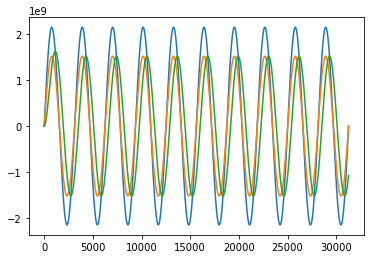

In [12]:
out = {
        'x': [],
        'y': []}

w00 = w0=w01=w1=y1=y=x1=0

for x_new in x_in:
    
    y = (b0x + w0) >> LOG_A0;
  
    b0x = b[0] * x
    a1y = a[1] * y
    b1x = b[1] * x
    a2y = a[2] * y
    b2x = b[2] * x

    
    w0 = b1x - a1y + w1;
    w1 = b2x - a2y;
    
    y = (b0x + w0) >> LOG_A0;
    w0 = b1x - a1y + w1;
    w1 = b2x - a2y;
    
    
    x = x1
    x = x_new << (DATA_WIDTH - IN_DATA_WIDTH)

    
    
    out['x'].append(x)
    out['y'].append(y)



plt.figure()
plt.plot(np.array(out['x']))
plt.plot(np.array(out['x'])/np.sqrt(2))
plt.plot(np.array(out['y']))




<ipython-input-27-3837fed98302>:15: RuntimeWarning: overflow encountered in scalar multiply
  b1_x1 = ( b[1] - b[0]*a[1] ) * x_1
<ipython-input-27-3837fed98302>:16: RuntimeWarning: overflow encountered in scalar multiply
  b2_x2 = ( b[2] + b[0]*a[2] - a[1]*b[1] ) * x_2


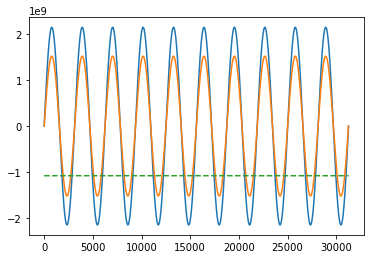

In [27]:
out = {
        'x': [],
        'y': []}


for x_new in x_in:
    
    
    y_4 = y_3 #4th fb delay
    y_3 = y_2 #3rd fb delay
    y_2 = y_1 #2nd fb delay
    y1 = (b0_x + b1_x1 + b2_x2 + b3_x3 + b4_x4 - a2_y2 - a4_y4) >> LOG_A0  #1st fb delay
    
    b0_x = b[0] * x
    b1_x1 = ( b[1] - b[0]*a[1] ) * x_1
    b2_x2 = ( b[2] + b[0]*a[2] - a[1]*b[1] ) * x_2
    b3_x3 = ( b[1]*a[2] - b[2]*a[1] ) * x_3
    b4_x4 = b[2]*a[2] * x_4
    
    a2_y2 = ( 2*a[2] - a[1]**2) * y_2
    a4_y4 = a[2]**2 * y_4
    
    x_4 = x_3
    x_3 = x_2
    x_2 = x_1
    x_1 = x
    x = x_new << (DATA_WIDTH - IN_DATA_WIDTH)

    
    
    out['x'].append(x)
    out['y'].append(y_1)



plt.figure()
plt.plot(np.array(out['x']))
plt.plot(np.array(out['x'])/np.sqrt(2))
plt.plot(np.array(out['y']),'--')




In [40]:
b[0],a[1], b[0]*a[1].astype('int64'), type(a[1])

(1078359, -1071585104, -1155553441164336, numpy.int32)

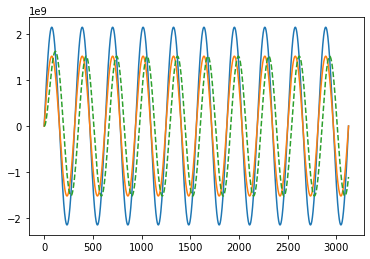

In [308]:
###TRANSPOSED DIRECT FORM 1

out = {
        'x': [],
        'y': []}

s1 = s1_old = s2 = s2_old = b0_x = b1_x = b2_x = a1_y = a2_y =0

for x0 in x_in:

    y = (b0_x + b2_x - a2_y + b1_x - a1_y) >> LOG_A0
     
    b0_x = b0_reg * x
    b1_x = b1_reg * x
    b2_x = b2_reg * x
    a1_y = a1_reg * y
    a2_y2 = a2_reg * y
    
        
    x = x0 << (DATA_WIDTH - IN_DATA_WIDTH)
   
    
    out['x'].append(x)
    out['y'].append(y)



plt.figure()
plt.plot(np.array(out['x']))
plt.plot(np.array(out['x'])/np.sqrt(2))
plt.plot(np.array(out['y']),'--')



In [125]:
#cutoff/nyq
### FIRST ORDER LOW PASS FILTER ###
iir_dict = {}
scale_factor = 2**30
sf = 1/(8e-9*4)
nyq = sf/2
b, a = butter(1, 1e-4, btype='low', analog=False)


### FIRST ORDER BAND PASS FILTER ###
iir_dict = {}
scale_factor = 2**30
sf = 1/(8e-9*4)
nyq = sf/2
f0 = 100000
Q = 100
w0 = 2 * np.pi * f0 / sf
alpha = np.sin(w0) / (2 * Q)
cos_w0 = np.cos(w0)
b  = np.array([alpha, 0, -alpha]) 
a = np.array([1 + alpha, -2 * cos_w0, 1 - alpha])

#b, a = iirfilter(1, [,2e-5+1e-5], btype='band', ftype='butter')




### JUST BASIC CHECK ###
b=np.array([1,0,0])
a=np.array([0,0,0])


#cutoff/nyq
### FIRST ORDER LOW PASS FILTER ###
iir_dict = {}
scale_factor = 2**30
sf = 1/(8e-9*4)/100
f0 = 1000
b, a = butter(1, f0/(sf/2), btype='low', analog=False)


print(a,b)

b = np.round(b * scale_factor).astype('int32')
a = np.round(a* scale_factor).astype('int32')

GAIN = 16

_, iir_dict['iir_a1'],iir_dict['iir_a2'] = np.pad(a, (0, 3 - len(a)), 'constant')
iir_dict['iir_b0'], iir_dict['iir_b1'],iir_dict['iir_b2'] = np.pad(b, (0, 3 - len(b)), 'constant')
iir_dict['gain'] = 2**GAIN


iir_dict, f0/(sf/2)

[ 1.         -0.98009326] [0.00995337 0.00995337]


({'iir_a1': -1052367125,
  'iir_a2': 0,
  'iir_b0': 10687349,
  'iir_b1': 10687349,
  'iir_b2': 0,
  'gain': 65536},
 0.006400000000000001)